In [1]:
#unhashtag this to install required libraries
#%pip install pandas numpy matplotlib scikit-learn seaborn shap

### ADDING FEATURES ###

import sys #System 
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import ops
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam    
from tensorflow.keras.metrics import Precision
from sklearn.preprocessing import StandardScaler
print(tf.__version__)



2.16.2


In [ ]:
#importing datasets
#Model Variables: Age, Bmi, Blood Glucose

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target = "HbA1c_level"

#Making y DataFrame for the model
y_train = train[target].astype("float32").values
y_test  = test[target].astype("float32").values

#train = train.drop(columns=["Unnamed: 0","former", "current", "ever", "never","no info", "not current", target, "male", "female", "other", "diabetes", "hypertension", "heart_disease", "diabetes"])
#test = test.drop(columns=["Unnamed: 0","former", "current", "ever", "never", "no info", "not current", target, "male", "female", "other", "diabetes", "hypertension", "heart_disease", "diabetes"])
#MODEL INCLUDES SMOKING HISTORY SINCE CLINICALLY IT ALSO AFFECTS HBA1C LEVELS  
train = train.drop(columns=["Unnamed: 0","former", "current", "ever", "never","no info", "not current", target, "male", "female", "other"])
test = test.drop(columns=["Unnamed: 0","former", "current", "ever", "never", "no info", "not current", target, "male", "female", "other"])
#train = train.drop(columns=["Unnamed: 0", target, "male", "female", "other"])
#test = test.drop(columns=["Unnamed: 0", target, "male", "female", "other"])


#Scaling continuous variables for easier use in model
#Binary columns are already created via preprocessing.
def separate_cols(x):
    bin_col = pd.DataFrame()
    cont_col = pd.DataFrame()
    for col in x.columns:
        if x[col].nunique() == 2:
            bin_col[col] = x[col].values
        else:
            cont_col[col] = x[col].values
    return bin_col, cont_col

train_bin, train_cont = separate_cols(train)
test_bin, test_cont = separate_cols(test)


from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

#Scaling
scaled_tr = sc.fit_transform(train_cont)
scaled_te = sc.transform(test_cont)

#making dataframes for scaled sets
scaled_tr_cont = pd.DataFrame(scaled_tr, columns = train_cont.columns)
scaled_te_cont = pd.DataFrame(scaled_te, columns = test_cont.columns)

#Creating the independent variable datasets 
x_train = pd.concat([train_bin, scaled_tr_cont], axis = 1)
x_test = pd.concat([test_bin, scaled_te_cont], axis = 1)


#Checking dataframe to have all of the columns
print(x_train)


       hypertension  heart_disease  diabetes  current  ever  former  never  \
0                 1              0         0        0     0       1      0   
1                 0              1         0        1     0       0      0   
2                 1              0         1        0     0       0      0   
3                 0              0         0        0     0       0      0   
4                 0              0         0        0     0       0      0   
...             ...            ...       ...      ...   ...     ...    ...   
76884             0              0         0        0     0       0      1   
76885             0              0         0        0     0       0      1   
76886             0              0         1        0     0       1      0   
76887             0              0         0        0     0       0      0   
76888             0              0         0        0     0       0      0   

       no info  not current       age       bmi  blood_glucose_

In [3]:
### Creating Sequential Model ###

model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(x_train.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(15, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823 (7.12 KB)

 Trainable params: 1,823 (7.12 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#Compiling to create backpropigation, loss and metrics
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
#Call back used to prevent overfitting
early_stop= tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)
callback = [early_stop, reduce_lr]
#Adam used as optimizer for backpropigation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

#Huber loss function used in regression problems
model.compile(optimizer=optimizer, loss="mse", metrics=["mae", "mse", tf.keras.metrics.RootMeanSquaredError(name="rmse")])
ann = model.fit(x_train,y_train,batch_size=128, epochs=200, validation_split=0.2, callbacks=[callback])

###uncomment this when wanting to train another model
#ann2 = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])



Epoch 1/200
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.8258 - mae: 3.5565 - mse: 14.8258 - rmse: 3.8504 - val_loss: 5.1527 - val_mae: 1.9650 - val_mse: 5.1527 - val_rmse: 2.2700 - learning_rate: 1.0000e-04
Epoch 2/200
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8014 - mae: 1.3738 - mse: 2.8014 - rmse: 1.6737 - val_loss: 2.0159 - val_mae: 1.1563 - val_mse: 2.0159 - val_rmse: 1.4198 - learning_rate: 1.0000e-04
Epoch 3/200
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7546 - mae: 1.0768 - mse: 1.7546 - rmse: 1.3246 - val_loss: 1.5531 - val_mae: 1.0213 - val_mse: 1.5531 - val_rmse: 1.2463 - learning_rate: 1.0000e-04
Epoch 4/200
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3960 - mae: 0.9707 - mse: 1.3960 - rmse: 1.1815 - val_loss: 1.2927 - val_mae: 0.9427 - val_mse: 1.2927 - val_rmse: 1.1370 - learning_rate: 1.0000e-04
Epoch 5/200
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1953 - mae: 0.9128 - mse: 1.1953 - rmse: 1.0933 - val_loss: 1.1465 - val_mae: 0.905

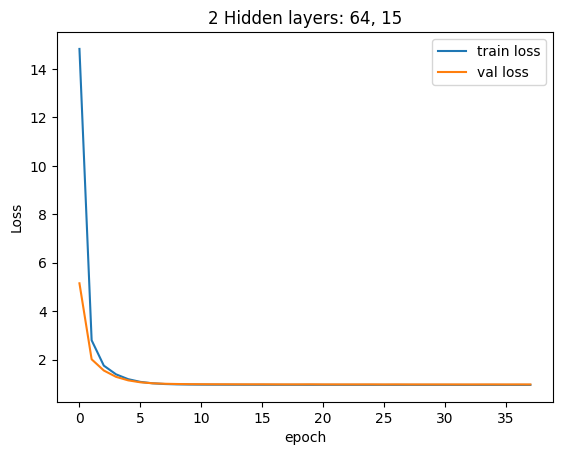

In [5]:
#Importing matplotlib here to start creating plots 
import matplotlib.pyplot as plt

#prints both loss and val_loss to see whether or not the model is learning and/or overfitting
#NOTE: If lines are close together, it means model is generalizing well since curve isn't deviating from the trained model.
plt.plot(ann.history['loss'], label='train loss')
plt.plot(ann.history['val_loss'], label='val loss')
plt.legend(); plt.title("2 Hidden layers: 64, 15"); plt.xlabel('epoch'); plt.ylabel('Loss'); plt.show()

    



In [6]:
#Testing the data
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_pred = model.predict(x_test,verbose=0).squeeze()

y_pred_df = pd.DataFrame({"y prediction": y_pred})
y_test_df = pd.DataFrame({"y actual": y_test})
predictions = pd.concat([y_pred_df, y_test_df], axis=1)
print(predictions)
#print(y_test)


loss, mae, mse, rmse = model.evaluate(x_test, y_test, verbose=1)

y_mean = np.full_like(y_test, y_test.mean(), dtype=float)
y_median = np.full_like(y_test, np.median(y_test), dtype=float)
mse_mean = mean_squared_error(y_test, y_mean)
mse_median = mean_squared_error(y_test, y_median)

improve_vs_mean = (1 - mse/mse_mean) if mse_mean > 0 else np.nan
improve_vs_median = (1 - mse/mse_median) if mse_median > 0 else np.nan


print(f"|Test Dataset loss: {loss:.4f} |Test MAE: {mae:.4f} |Test RMSE: {rmse:.4f}|\n")
print("Baseline (mean) mse:", mse_mean)
print("Baseline (median) mse:", mse_median)
print("Improvement vs Mean:", improve_vs_mean)
print("Improvement vs Median:", improve_vs_median)







       y prediction  y actual
0          5.437232       6.6
1          5.521236       4.8
2          5.406527       5.0
3          5.443683       6.1
4          5.417651       6.1
...             ...       ...
19218      5.431579       4.0
19219      6.882612       6.2
19220      5.369823       5.8
19221      5.461539       6.0
19222      5.358943       6.5

[19223 rows x 2 columns]
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9706 - mae: 0.8627 - mse: 0.9706 - rmse: 0.9852
|Test Dataset loss: 0.9706 |Test MAE: 0.8627 |Test RMSE: 0.9852|

Baseline (mean) mse: 1.1587101512500375
Baseline (median) mse: 1.2307054562865167
Improvement vs Mean: 0.1623084244418369
Improvement vs Median: 0.21131272534968815


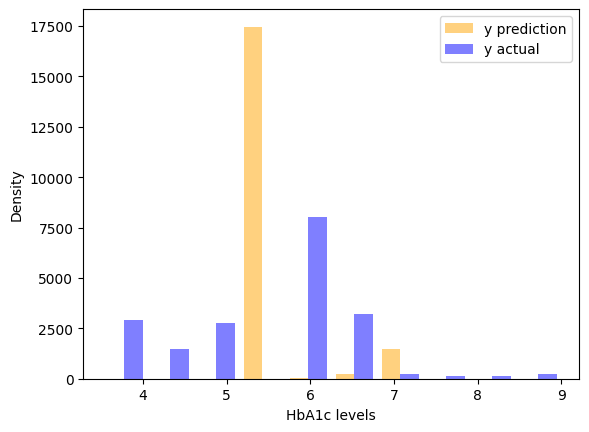

In [7]:
# Histogram with density
plt.hist(predictions, alpha=0.5, color=["orange", "blue"])
plt.legend(predictions)

# Plot a line through the histogram (midpoints vs density)
plt.xlabel("HbA1c levels")
plt.ylabel("Density")
plt.show()


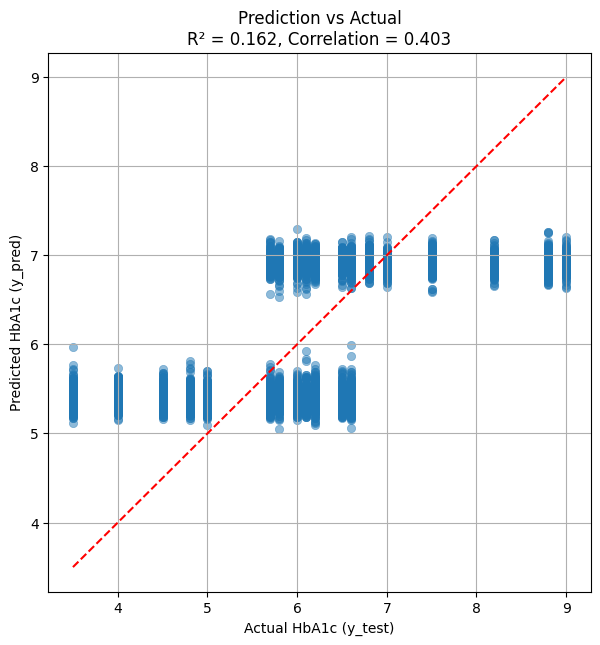

In [8]:
import seaborn as sns
from sklearn.metrics import r2_score
# Compute correlation (R² and Pearson's r) to test the correlation between the Actual hba1c and Predicted hba1c
#These variables are to be used in the title
r2 = r2_score(y_test, y_pred)
corr = np.corrcoef(y_test, y_pred)[0,1]

# Plot correlation scatter
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line

#Adding the lables to make the graph understandable.
plt.xlabel("Actual HbA1c (y_test)")
plt.ylabel("Predicted HbA1c (y_pred)")
plt.title(f"Prediction vs Actual\nR² = {r2:.3f}, Correlation = {corr:.3f}")
plt.grid(True)
plt.show()

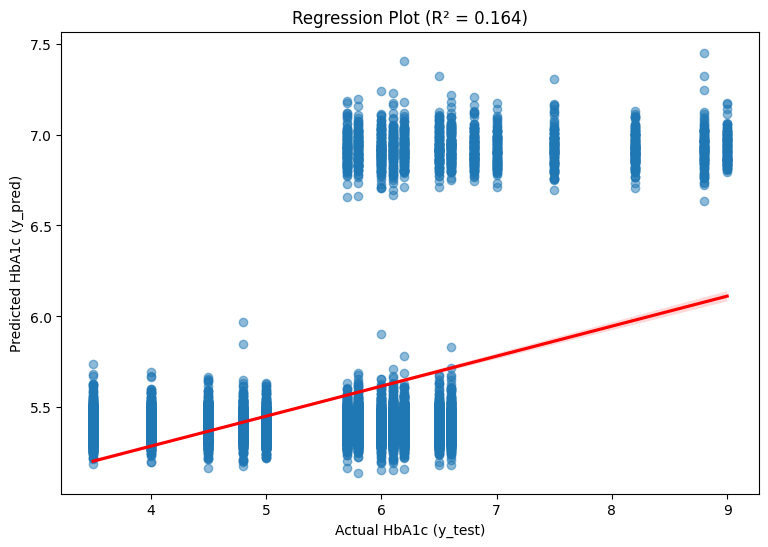

In [34]:
#Regression plot is used as another means to 
y_pred = y_pred.flatten()

# Compute R²
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(9,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})

plt.xlabel("Actual HbA1c (y_test)")
plt.ylabel("Predicted HbA1c (y_pred)")
plt.title(f"Regression Plot (R² = {r2:.3f})")

plt.show()

In [20]:
#Using shap to test feature importance in our dataset.

import shap


explainer = shap.Explainer(model, x_train)
shap_values = explainer(x_test)
# Summary plot (feature importance as beeswarm)
#shap.summary_plot(shap_values, x_test, feature_names=x_test.columns)

# Bar plot of average absolute importance
#shap.summary_plot(shap_values, x_test, feature_names=x_test.columns, plot_type="bar")

PermutationExplainer explainer:  14%|█▎        | 2632/19223 [07:42<50:30,  5.47it/s]    


KeyboardInterrupt: 

In [ ]:
#print(x_test)
#print(y_test_df)

In [ ]:
#Writing predictions into csv

#predictions.to_csv("prediction_continuous.csv", index=False)

#pd.DataFrame(ann.history).to_csv("training_hba1c.csv", index=False)

In [ ]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_train, y_train)
#print("Baseline R^2 (train):", reg.score(x_train, y_train))
#print("Baseline R^2 (test):", reg.score(x_test, y_test))
